## Exercise: Expanding Rule-Based Sentiment Analysis with TextBlob

**Objective:** Your goal is to apply TextBlob for sentiment analysis on various types of text, interpret the results (polarity and subjectivity), and potentially extend its functionality.

**Instructions:**

1.  **Installation (if necessary):** Ensure `textblob` is installed. If not, run the provided `pip install` command in a code cell.
2.  **Analyze Diverse Texts:** Use the provided TextBlob sentiment analysis code on the following sentences:
    *   **Positive:** "The weather is absolutely beautiful today, I'm so happy!"
    *   **Negative:** "I am extremely disappointed with the service; it was terrible."
    *   **Neutral:** "The capital of France is Paris."
    *   **Mixed:** "The movie had a great plot, but the acting was dreadful."
3.  **Interpret Polarity and Subjectivity:** For each sentence, note down the `polarity` and `subjectivity` scores. Explain in your own words what each score indicates for that specific sentence.
4.  **Batch Processing (Optional Challenge):** Write a simple Python function that takes a list of sentences and returns a list of dictionaries, where each dictionary contains the original sentence, its polarity, and its subjectivity.
5.  **Reflect:** How well does TextBlob handle neutral sentences or sentences with mixed sentiments?

In [3]:
# Step 1: Install TextBlob (if not already installed)
# !pip install textblob

from textblob import TextBlob

# Step 2: Analyze Diverse Texts

sentences = [
    "The weather is absolutely beautiful today, I'm so happy!",
    "I am extremely disappointed with the service; it was terrible.",
    "The capital of France is Paris.",
    "The movie had a great plot, but the acting was dreadful."
]

# Step 3: Interpretation of Polarity and Subjectivity Scores

print("Sentiment Analysis Results:")
for i, text in enumerate(sentences):
    blob = TextBlob(text)
    sentiment = blob.sentiment
    print(f"\nSentence {i+1}: '{text}'")
    print(f"  Polarity: {sentiment.polarity:.2f}, Subjectivity: {sentiment.subjectivity:.2f}")

# Step 4 Implement the batch processing function here
def analyze_sentences(sentence_list):
    results = []
    for sentence in sentence_list:
        blob = TextBlob(sentence)
        sentiment = blob.sentiment
        results.append({
            "sentence": sentence,
            "polarity": sentiment.polarity,
            "subjectivity": sentiment.subjectivity
        })
    return results

# Example usage for the challenge:
print("\nBatch Processing Results:")
analysis_results = analyze_sentences(sentences)
for result in analysis_results:
    print(result)

Sentiment Analysis Results:

Sentence 1: 'The weather is absolutely beautiful today, I'm so happy!'
  Polarity: 0.93, Subjectivity: 1.00

Sentence 2: 'I am extremely disappointed with the service; it was terrible.'
  Polarity: -0.88, Subjectivity: 0.88

Sentence 3: 'The capital of France is Paris.'
  Polarity: 0.00, Subjectivity: 0.00

Sentence 4: 'The movie had a great plot, but the acting was dreadful.'
  Polarity: -0.07, Subjectivity: 0.58

Batch Processing Results:
{'sentence': "The weather is absolutely beautiful today, I'm so happy!", 'polarity': 0.925, 'subjectivity': 1.0}
{'sentence': 'I am extremely disappointed with the service; it was terrible.', 'polarity': -0.875, 'subjectivity': 0.875}
{'sentence': 'The capital of France is Paris.', 'polarity': 0.0, 'subjectivity': 0.0}
{'sentence': 'The movie had a great plot, but the acting was dreadful.', 'polarity': -0.06666666666666665, 'subjectivity': 0.5833333333333334}


### Challenges: Advanced Sentiment Categorization and Distribution

1.  **Define Sentiment Categories:** Create a Python function, `get_sentiment_category(polarity_score)`, that takes a polarity score as input and returns one of three strings: "Positive", "Negative", or "Neutral". You will need to define clear thresholds for these categories (e.g., polarity > 0.1 for Positive, polarity < -0.1 for Negative, otherwise Neutral).
2.  **Apply Categorization:** Modify the `analyze_sentences` function (or create a new function) to include this sentiment category in the output dictionary for each sentence.
3.  **Calculate Distribution:** After processing the sentences, calculate and print the total count or percentage of sentences falling into each category (Positive, Negative, Neutral).
4.  **(Optional) Visualize Distribution:** Use a library like `matplotlib` or `seaborn` to create a bar chart showing the distribution of sentiment categories.


Advanced Sentiment Analysis Results with Categories:
{'sentence': "The weather is absolutely beautiful today, I'm so happy!", 'polarity': 0.925, 'subjectivity': 1.0, 'sentiment_category': 'Positive'}
{'sentence': 'I am extremely disappointed with the service; it was terrible.', 'polarity': -0.875, 'subjectivity': 0.875, 'sentiment_category': 'Negative'}
{'sentence': 'The capital of France is Paris.', 'polarity': 0.0, 'subjectivity': 0.0, 'sentiment_category': 'Neutral'}
{'sentence': 'The movie had a great plot, but the acting was dreadful.', 'polarity': -0.06666666666666665, 'subjectivity': 0.5833333333333334, 'sentiment_category': 'Neutral'}

Sentiment Distribution:
Positive: 1 (25.00%)
Negative: 1 (25.00%)
Neutral: 2 (50.00%)


/var/folders/rp/pn828d7n1sjc3yl0j4n4lr2c0000gn/T/ipykernel_8867/1871809069.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette='viridis')


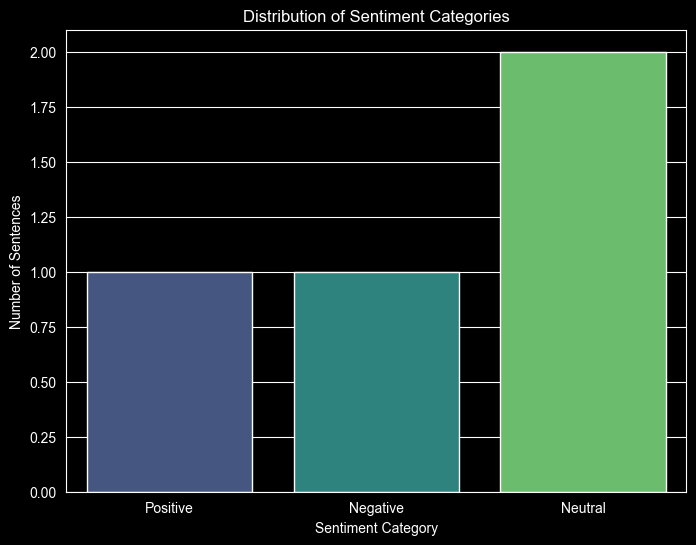

In [4]:
# Complete the ?? in the code below.

# Step 1: Define the sentiment categorization function
def get_sentiment_category(polarity_score):
    if polarity_score > 0.1:
        return "Positive"
    elif polarity_score < -0.1:
        return "Negative"
    else:
        return "Neutral"


# Step 2: Modify analyze_sentences to include sentiment category
def analyze_sentences_with_category(sentence_list):
    results = []
    for sentence in sentence_list:
        blob = TextBlob(sentence)
        sentiment = blob.sentiment
        results.append({
            "sentence": sentence,
            "polarity": sentiment.polarity,
            "subjectivity": sentiment.subjectivity,
            "sentiment_category": get_sentiment_category(sentiment.polarity)
        })
    return results


# Step 3: Apply the new function and calculate distribution
analysis_with_categories = analyze_sentences_with_category(sentences)

print("\nAdvanced Sentiment Analysis Results with Categories:")
for result in analysis_with_categories:
    print(result)

# Calculate distribution
sentiment_counts = {'Positive': 0, 'Negative': 0, 'Neutral': 0}
for result in analysis_with_categories:
    sentiment_counts[result['sentiment_category']] += 1

total_sentences = len(sentences)
print("\nSentiment Distribution:")
for category, count in sentiment_counts.items():
    percentage = (count / total_sentences) * 100
    print(f"{category}: {count} ({percentage:.2f}%)")

# Step 4: (Optional) Visualize Distribution
import matplotlib.pyplot as plt
import seaborn as sns

categories = list(sentiment_counts.keys())
counts = list(sentiment_counts.values())

plt.figure(figsize=(8, 6))
sns.barplot(x=categories, y=counts, palette='viridis')
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Sentences')
plt.show()